# Dataset Generalization

This notebook tests whether the observed disagreement structure generalizes across synthetic datasets.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [37]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Multi-Dataset Synthetic Generation

We generate a suite of varied synthetic datasets (circles, moons, XOR, checkerboard) to ensure our findings are not artifacts of a single topology.

In [38]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, make_blobs, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [39]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

# CPU is safest and fast enough for these small experiments on Mac.
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

In [40]:
import matplotlib.pyplot as plt

plt.style.use("default")

In [41]:
# -----------------------------------------------------------------------------
# Dataset generators
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_spiral(n_samples=1500, noise=0.18, random_state=42):
    rng = np.random.default_rng(random_state)
    n_per_class = n_samples // 2
    X_parts = []
    y_parts = []

    for cls in [0, 1]:
        r = np.linspace(0.15, 1.7, n_per_class)
        theta = np.linspace(0, 3.5 * np.pi, n_per_class) + cls * np.pi
        theta += rng.normal(scale=noise, size=n_per_class)
        x1 = r * np.cos(theta)
        x2 = r * np.sin(theta)
        X_parts.append(np.c_[x1, x2])
        y_parts.append(np.full(n_per_class, cls))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    # Nonlinear coordinate warp creates a curved decision structure while preserving
    # relatively simple class clusters.
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])
    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    X += rng.normal(scale=noise, size=X.shape)

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, noise=0.25, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=noise, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, noise=noise, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, noise=0.03, random_state=random_state)
    if name == "spiral":
        return make_spiral(n_samples=n_samples, noise=0.18, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, noise=0.08, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, noise=0.05, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, noise=0.0, random_state=random_state)
    if name == "high_dimensional":
        return make_classification(
            n_samples=n_samples,
            n_features=10,
            n_informative=5,
            n_redundant=2,
            n_repeated=0,
            n_classes=2,
            class_sep=1.1,
            flip_y=0.03,
            random_state=random_state,
        )
    raise ValueError(f"Unknown dataset: {name}")


### Model Training

Here we initialize and train the teacher models, followed by the respective surrogate approximation models.

In [42]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


In [43]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    """Train a surrogate to mimic the teacher's hard decisions."""
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Cross-Dataset Gap Analysis

We compute the global-local fidelity gap across all synthetic datasets to prove that the structural concentration of disagreement generalizes across diverse geometries.

In [44]:
# -----------------------------------------------------------------------------
# Metrics
# -----------------------------------------------------------------------------

def compute_metrics(y_true, teacher_p, surrogate_p, eps=0.10):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)

    boundary_mask = np.abs(teacher_p - 0.5) <= eps
    nonboundary_mask = ~boundary_mask

    metrics = {
        "teacher_task_accuracy": accuracy_score(y_true, teacher_y),
        "surrogate_task_accuracy": accuracy_score(y_true, surrogate_y),
        "global_fidelity": accuracy_score(teacher_y, surrogate_y),
        "probability_mse": mean_squared_error(teacher_p, surrogate_p),
        "n_boundary_points": int(boundary_mask.sum()),
        "boundary_fraction": float(boundary_mask.mean()),
    }

    if boundary_mask.sum() > 0:
        metrics["boundary_fidelity"] = accuracy_score(teacher_y[boundary_mask], surrogate_y[boundary_mask])
        metrics["boundary_task_accuracy"] = accuracy_score(y_true[boundary_mask], surrogate_y[boundary_mask])
    else:
        metrics["boundary_fidelity"] = np.nan
        metrics["boundary_task_accuracy"] = np.nan

    if nonboundary_mask.sum() > 0:
        metrics["nonboundary_fidelity"] = accuracy_score(teacher_y[nonboundary_mask], surrogate_y[nonboundary_mask])
    else:
        metrics["nonboundary_fidelity"] = np.nan

    metrics["boundary_gap"] = metrics["global_fidelity"] - metrics["boundary_fidelity"]
    return metrics


In [45]:
# -----------------------------------------------------------------------------
# Experiment runner
# -----------------------------------------------------------------------------

def run_one(dataset_name, seed, surrogate_name, eps=0.10, n_samples=1500):
    X, y = load_dataset(dataset_name, n_samples=n_samples, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)

    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)
    surrogate_test_p = surrogate_probs(surrogate, X_test)

    metrics = compute_metrics(y_test, teacher_test_p, surrogate_test_p, eps=eps)
    metrics["dataset"] = dataset_name
    metrics["seed"] = seed
    metrics["surrogate"] = surrogate_name
    metrics["eps"] = eps
    return metrics


In [46]:
datasets = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "circles",
    "xor",
    "checkerboard",
    "high_dimensional",
]

surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

seeds = list(range(10))
eps = 0.10

rows = []
for dataset_name in datasets:
    print(f"\n=== Dataset: {dataset_name} ===")
    for seed in seeds:
        print(f"  seed {seed}")
        for surrogate_name in surrogates:
            row = run_one(dataset_name, seed, surrogate_name, eps=eps, n_samples=1500)
            rows.append(row)

results = pd.DataFrame(rows)
results



=== Dataset: moons ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: warped_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: gaussian_overlap ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: linear_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: circles ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: xor ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: checkerboard ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9

=== Dataset: high_dimensional ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4
  seed 5
  seed 6
  seed 7
  seed 8
  seed 9


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,dataset,seed,surrogate,eps
0,0.914286,0.840000,0.883810,0.059355,10,0.019048,0.800,0.300,0.885437,0.083810,moons,0,logistic_regression,0.1
1,0.914286,0.840000,0.883810,0.059148,10,0.019048,0.800,0.300,0.885437,0.083810,moons,0,linear_svm_calibrated,0.1
2,0.914286,0.878095,0.929524,0.045969,10,0.019048,0.700,0.200,0.933981,0.229524,moons,0,decision_tree_depth_2,0.1
3,0.914286,0.878095,0.929524,0.036599,10,0.019048,0.700,0.200,0.933981,0.229524,moons,0,decision_tree_depth_4,0.1
4,0.914286,0.840000,0.883810,0.059026,10,0.019048,0.800,0.300,0.885437,0.083810,moons,0,small_mlp_surrogate,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.874286,0.708571,0.716190,0.171718,8,0.015238,0.500,0.250,0.719536,0.216190,high_dimensional,9,logistic_regression,0.1
396,0.874286,0.708571,0.720000,0.171490,8,0.015238,0.500,0.250,0.723404,0.220000,high_dimensional,9,linear_svm_calibrated,0.1
397,0.874286,0.744762,0.737143,0.176275,8,0.015238,0.500,0.500,0.740812,0.237143,high_dimensional,9,decision_tree_depth_2,0.1
398,0.874286,0.777143,0.765714,0.157600,8,0.015238,0.625,0.625,0.767892,0.140714,high_dimensional,9,decision_tree_depth_4,0.1


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [47]:
# Save raw results immediately.
results.to_csv("dataset_generalization_raw_results.csv", index=False)
print("Saved dataset_generalization_raw_results.csv")


Saved dataset_generalization_raw_results.csv


In [48]:
summary = (
    results
    .groupby(["dataset", "surrogate"])
    .agg(
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        teacher_task_accuracy_std=("teacher_task_accuracy", "std"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        surrogate_task_accuracy_std=("surrogate_task_accuracy", "std"),
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        nonboundary_fidelity_std=("nonboundary_fidelity", "std"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        probability_mse_mean=("probability_mse", "mean"),
    )
    .reset_index()
    .sort_values(["dataset", "boundary_gap_mean"], ascending=[True, False])
)

summary


,dataset,surrogate,teacher_task_accuracy_mean,teacher_task_accuracy_std,surrogate_task_accuracy_mean,surrogate_task_accuracy_std,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,nonboundary_fidelity_std,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean,probability_mse_mean
1,checkerboard,decision_tree_depth_4,0.943238,0.010230,0.651810,0.100702,0.662857,0.108254,0.479503,0.107660,0.669142,0.112805,0.183354,0.172964,0.034286,0.158434
3,checkerboard,logistic_regression,0.943238,0.010230,0.498286,0.030452,0.510095,0.023082,0.440789,0.178048,0.512063,0.026997,0.069306,0.194847,0.034286,0.211484
0,checkerboard,decision_tree_depth_2,0.943238,0.010230,0.535619,0.050426,0.541714,0.048046,0.485881,0.115047,0.543260,0.049183,0.055833,0.115174,0.034286,0.206258
2,checkerboard,linear_svm_calibrated,0.943238,0.010230,0.509333,0.021441,0.523810,0.025301,0.469092,0.202559,0.524547,0.027604,0.054718,0.208544,0.034286,0.211273
4,checkerboard,small_mlp_surrogate,0.943238,0.010230,0.525524,0.036655,0.528571,0.024888,0.534988,0.085115,0.528144,0.026556,-0.006417,0.091028,0.034286,0.201129
9,circles,small_mlp_surrogate,0.850857,0.015476,0.850667,0.012481,0.963619,0.013836,0.631434,0.111125,0.990554,0.009505,0.332185,0.099900,0.074095,0.009200
6,circles,decision_tree_depth_4,0.850857,0.015476,0.837143,0.020043,0.924571,0.018075,0.600275,0.081387,0.950570,0.016425,0.324297,0.074946,0.074095,0.039956
5,circles,decision_tree_depth_2,0.850857,0.015476,0.691619,0.020027,0.746667,0.019362,0.524102,0.061313,0.764647,0.023636,0.222565,0.073392,0.074095,0.108920
7,circles,linear_svm_calibrated,0.850857,0.015476,0.506476,0.039513,0.514667,0.048544,0.427711,0.073928,0.521555,0.051194,0.086955,0.079774,0.074095,0.157736
8,circles,logistic_regression,0.850857,0.015476,0.541714,0.064999,0.559810,0.063215,0.492493,0.103021,0.564875,0.064404,0.067317,0.091065,0.074095,0.158168


In [49]:
summary.to_csv("dataset_generalization_summary_by_dataset_surrogate.csv", index=False)
print("Saved dataset_generalization_summary_by_dataset_surrogate.csv")


Saved dataset_generalization_summary_by_dataset_surrogate.csv


In [50]:
# Dataset-level view averaged over surrogate families and seeds.
dataset_summary = (
    results
    .groupby("dataset")
    .agg(
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
    )
    .sort_values("boundary_gap_mean", ascending=False)
)

dataset_summary


,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean
dataset,,,,,,,,,,
linear_blobs,0.994286,0.994248,0.997524,0.002411,0.600000,0.516398,0.997676,0.398667,0.515087,0.000381
moons,0.931238,0.874857,0.904457,0.034826,0.572035,0.157388,0.911983,0.332422,0.155132,0.022286
high_dimensional,0.914095,0.847048,0.864000,0.071970,0.536111,0.348257,0.866595,0.321328,0.326017,0.006476
warped_blobs,0.969333,0.969143,0.990743,0.006145,0.696775,0.239589,0.994515,0.293968,0.237646,0.014095
gaussian_overlap,0.755429,0.747390,0.893067,0.051560,0.685735,0.120608,0.948766,0.207331,0.081581,0.215238
circles,0.850857,0.685524,0.741867,0.188368,0.535203,0.112419,0.758441,0.206664,0.139730,0.074095
xor,0.846476,0.682705,0.737943,0.203502,0.592040,0.107455,0.753596,0.145903,0.155140,0.097714
checkerboard,0.943238,0.544114,0.553410,0.077883,0.482051,0.142153,0.555431,0.071359,0.168272,0.034286


In [51]:
dataset_summary.to_csv("dataset_generalization_dataset_summary.csv")
print("Saved dataset_generalization_dataset_summary.csv")


Saved dataset_generalization_dataset_summary.csv


In [52]:
# Paired tests: global fidelity vs. boundary fidelity, grouped by dataset and surrogate.
stat_rows = []
for (dataset_name, surrogate_name), group in results.groupby(["dataset", "surrogate"]):
    clean = group[["global_fidelity", "boundary_fidelity"]].dropna()
    diff = clean["global_fidelity"] - clean["boundary_fidelity"]

    if len(clean) >= 2:
        t_stat, p_val = stats.ttest_rel(clean["global_fidelity"], clean["boundary_fidelity"])
        dz = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan
    else:
        t_stat, p_val, dz = np.nan, np.nan, np.nan

    stat_rows.append({
        "dataset": dataset_name,
        "surrogate": surrogate_name,
        "n": len(clean),
        "mean_global_fidelity": clean["global_fidelity"].mean(),
        "mean_boundary_fidelity": clean["boundary_fidelity"].mean(),
        "mean_gap": diff.mean(),
        "std_gap": diff.std(ddof=1),
        "paired_t": t_stat,
        "p_value": p_val,
        "cohens_dz": dz,
    })

stats_table = pd.DataFrame(stat_rows).sort_values(["dataset", "mean_gap"], ascending=[True, False])
stats_table


,dataset,surrogate,n,mean_global_fidelity,mean_boundary_fidelity,mean_gap,std_gap,paired_t,p_value,cohens_dz
1,checkerboard,decision_tree_depth_4,10,0.662857,0.479503,0.183354,0.172964,3.352233,8.493346e-03,1.060069
3,checkerboard,logistic_regression,10,0.510095,0.440789,0.069306,0.194847,1.124812,2.897712e-01,0.355697
0,checkerboard,decision_tree_depth_2,10,0.541714,0.485881,0.055833,0.115174,1.532974,1.596478e-01,0.484769
2,checkerboard,linear_svm_calibrated,10,0.523810,0.469092,0.054718,0.208544,0.829715,4.281582e-01,0.262379
4,checkerboard,small_mlp_surrogate,10,0.528571,0.534988,-0.006417,0.091028,-0.222925,8.285709e-01,-0.070495
9,circles,small_mlp_surrogate,10,0.963619,0.631434,0.332185,0.099900,10.515091,2.352036e-06,3.325164
6,circles,decision_tree_depth_4,10,0.924571,0.600275,0.324297,0.074946,13.683452,2.498456e-07,4.327088
5,circles,decision_tree_depth_2,10,0.746667,0.524102,0.222565,0.073392,9.589718,5.065538e-06,3.032535
7,circles,linear_svm_calibrated,10,0.514667,0.427711,0.086955,0.079774,3.446962,7.309690e-03,1.090025
8,circles,logistic_regression,10,0.559810,0.492493,0.067317,0.091065,2.337621,4.419216e-02,0.739221


In [53]:
stats_table.to_csv("dataset_generalization_paired_tests.csv", index=False)
print("Saved dataset_generalization_paired_tests.csv")


Saved dataset_generalization_paired_tests.csv


In [54]:
# Compact table: one row per dataset/surrogate.
def fmt_mean_std(mean, std):
    return f"{mean:.3f} ± {std:.3f}"

compact_rows = []
for _, row in summary.iterrows():
    compact_rows.append({
        "dataset": row["dataset"],
        "surrogate": row["surrogate"],
        "teacher acc": fmt_mean_std(row["teacher_task_accuracy_mean"], row["teacher_task_accuracy_std"]),
        "surrogate acc": fmt_mean_std(row["surrogate_task_accuracy_mean"], row["surrogate_task_accuracy_std"]),
        "global fidelity": fmt_mean_std(row["global_fidelity_mean"], row["global_fidelity_std"]),
        "boundary fidelity": fmt_mean_std(row["boundary_fidelity_mean"], row["boundary_fidelity_std"]),
        "nonboundary fidelity": fmt_mean_std(row["nonboundary_fidelity_mean"], row["nonboundary_fidelity_std"]),
        "gap": fmt_mean_std(row["boundary_gap_mean"], row["boundary_gap_std"]),
        "boundary fraction": f"{row['boundary_fraction_mean']:.3f}",
    })

compact = pd.DataFrame(compact_rows)
compact


,dataset,surrogate,teacher acc,surrogate acc,global fidelity,boundary fidelity,nonboundary fidelity,gap,boundary fraction
0,checkerboard,decision_tree_depth_4,0.943 ± 0.010,0.652 ± 0.101,0.663 ± 0.108,0.480 ± 0.108,0.669 ± 0.113,0.183 ± 0.173,0.034
1,checkerboard,logistic_regression,0.943 ± 0.010,0.498 ± 0.030,0.510 ± 0.023,0.441 ± 0.178,0.512 ± 0.027,0.069 ± 0.195,0.034
2,checkerboard,decision_tree_depth_2,0.943 ± 0.010,0.536 ± 0.050,0.542 ± 0.048,0.486 ± 0.115,0.543 ± 0.049,0.056 ± 0.115,0.034
3,checkerboard,linear_svm_calibrated,0.943 ± 0.010,0.509 ± 0.021,0.524 ± 0.025,0.469 ± 0.203,0.525 ± 0.028,0.055 ± 0.209,0.034
4,checkerboard,small_mlp_surrogate,0.943 ± 0.010,0.526 ± 0.037,0.529 ± 0.025,0.535 ± 0.085,0.528 ± 0.027,-0.006 ± 0.091,0.034
5,circles,small_mlp_surrogate,0.851 ± 0.015,0.851 ± 0.012,0.964 ± 0.014,0.631 ± 0.111,0.991 ± 0.010,0.332 ± 0.100,0.074
6,circles,decision_tree_depth_4,0.851 ± 0.015,0.837 ± 0.020,0.925 ± 0.018,0.600 ± 0.081,0.951 ± 0.016,0.324 ± 0.075,0.074
7,circles,decision_tree_depth_2,0.851 ± 0.015,0.692 ± 0.020,0.747 ± 0.019,0.524 ± 0.061,0.765 ± 0.024,0.223 ± 0.073,0.074
8,circles,linear_svm_calibrated,0.851 ± 0.015,0.506 ± 0.040,0.515 ± 0.049,0.428 ± 0.074,0.522 ± 0.051,0.087 ± 0.080,0.074
9,circles,logistic_regression,0.851 ± 0.015,0.542 ± 0.065,0.560 ± 0.063,0.492 ± 0.103,0.565 ± 0.064,0.067 ± 0.091,0.074


In [55]:
compact.to_csv("dataset_generalization_compact_summary.csv", index=False)
print("Saved dataset_generalization_compact_summary.csv")


Saved dataset_generalization_compact_summary.csv


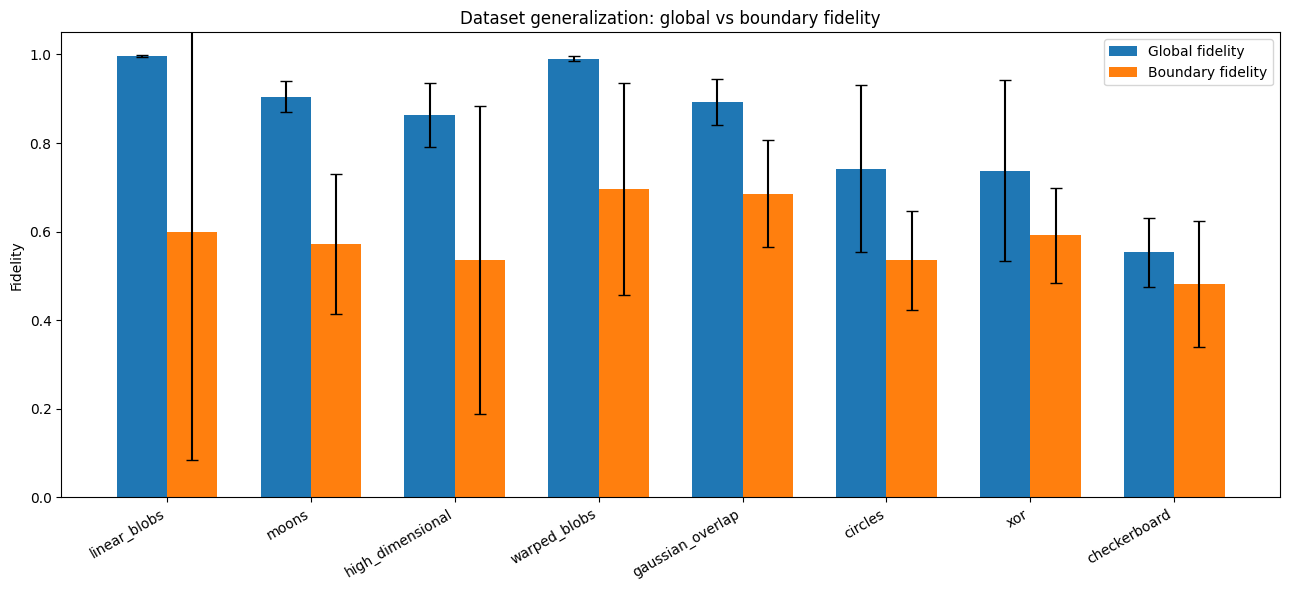

In [56]:
# Plot dataset-level global vs boundary fidelity.
ordered_datasets = dataset_summary.index.tolist()
positions = np.arange(len(ordered_datasets))
width = 0.35

global_means = [dataset_summary.loc[d, "global_fidelity_mean"] for d in ordered_datasets]
global_stds = [dataset_summary.loc[d, "global_fidelity_std"] for d in ordered_datasets]
boundary_means = [dataset_summary.loc[d, "boundary_fidelity_mean"] for d in ordered_datasets]
boundary_stds = [dataset_summary.loc[d, "boundary_fidelity_std"] for d in ordered_datasets]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(positions - width / 2, global_means, width, yerr=global_stds, capsize=4, label="Global fidelity")
ax.bar(positions + width / 2, boundary_means, width, yerr=boundary_stds, capsize=4, label="Boundary fidelity")
ax.set_xticks(positions)
ax.set_xticklabels(ordered_datasets, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fidelity")
ax.set_title("Dataset generalization: global vs boundary fidelity")
ax.legend()
plt.tight_layout()
plt.savefig("dataset_generalization_global_vs_boundary.png", dpi=200)
plt.show()


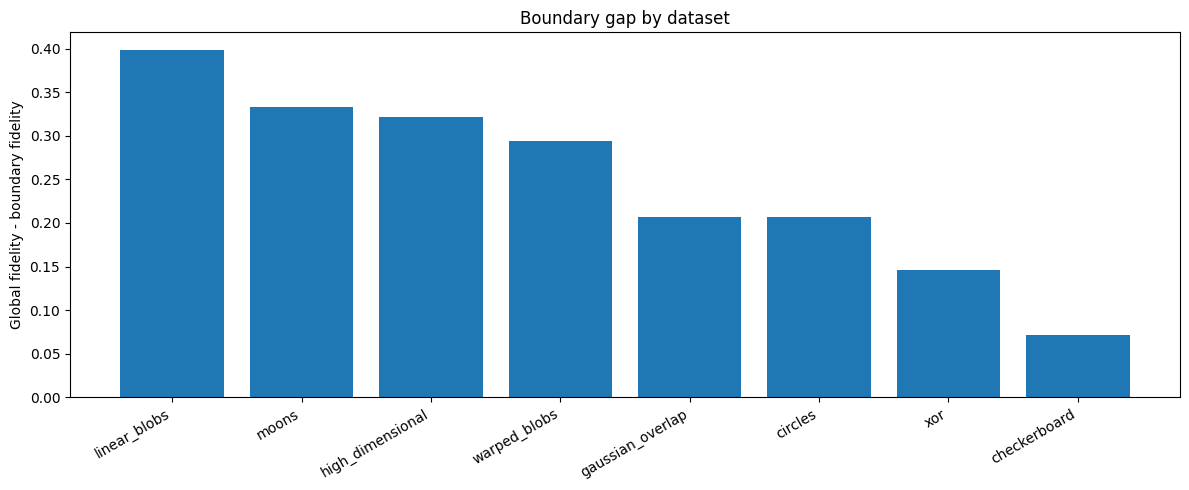

In [57]:
# Plot boundary gap by dataset, averaged across surrogates and seeds.
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ordered_datasets, [dataset_summary.loc[d, "boundary_gap_mean"] for d in ordered_datasets])
ax.set_xticklabels(ordered_datasets, rotation=30, ha="right")
ax.set_ylabel("Global fidelity - boundary fidelity")
ax.set_title("Boundary gap by dataset")
plt.tight_layout()
plt.savefig("dataset_generalization_boundary_gap_by_dataset.png", dpi=200)
plt.show()


In [58]:
# Heatmap-like visualization of mean boundary gaps by dataset and surrogate.
gap_pivot = summary.pivot(index="dataset", columns="surrogate", values="boundary_gap_mean")
gap_pivot = gap_pivot.loc[ordered_datasets]

gap_pivot


surrogate,decision_tree_depth_2,decision_tree_depth_4,linear_svm_calibrated,logistic_regression,small_mlp_surrogate
dataset,,,,,
linear_blobs,0.499048,0.499048,0.498095,0.498095,-0.000952
moons,0.359448,0.359448,0.314423,0.315185,0.313606
high_dimensional,0.297672,0.260450,0.352804,0.331217,0.364497
warped_blobs,0.204440,0.192628,0.321147,0.380075,0.371551
gaussian_overlap,0.185368,0.152277,0.248995,0.250504,0.199512
circles,0.222565,0.324297,0.086955,0.067317,0.332185
xor,0.177800,0.263030,-0.002141,0.008815,0.282011
checkerboard,0.055833,0.183354,0.054718,0.069306,-0.006417


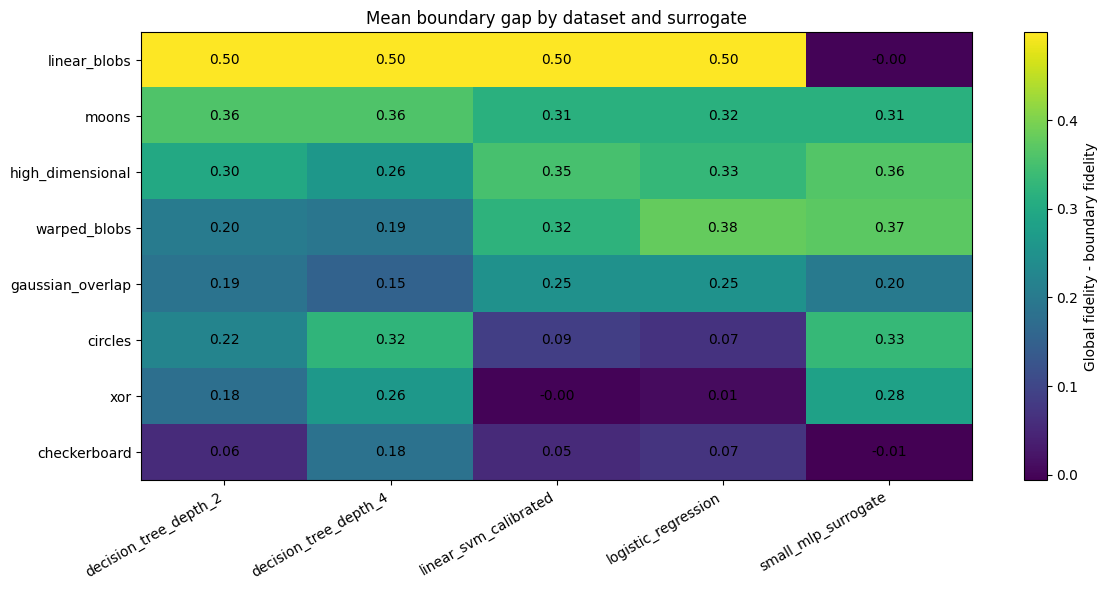

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(gap_pivot.values, aspect="auto")

ax.set_xticks(np.arange(gap_pivot.shape[1]))
ax.set_xticklabels(gap_pivot.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(gap_pivot.shape[0]))
ax.set_yticklabels(gap_pivot.index)
ax.set_title("Mean boundary gap by dataset and surrogate")

for i in range(gap_pivot.shape[0]):
    for j in range(gap_pivot.shape[1]):
        ax.text(j, i, f"{gap_pivot.values[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Global fidelity - boundary fidelity")
plt.tight_layout()
plt.savefig("dataset_generalization_gap_heatmap.png", dpi=200)
plt.show()


In [60]:
# 2D visualization helper for a single dataset/seed/surrogate.
def make_grid(X, margin=0.7, grid_size=300):
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def visualize_2d_case(dataset_name, surrogate_name="logistic_regression", seed=0, eps=0.10):
    X, y = load_dataset(dataset_name, n_samples=1500, random_state=seed)
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)
    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)

    xx, yy, grid = make_grid(X)
    teacher_grid_p = teacher_probs(teacher, grid).reshape(xx.shape)
    surrogate_grid_p = surrogate_probs(surrogate, grid).reshape(xx.shape)
    disagreement = ((teacher_grid_p >= 0.5) != (surrogate_grid_p >= 0.5)).astype(int)
    boundary_region = (np.abs(teacher_grid_p - 0.5) <= eps).astype(int)

    metrics = compute_metrics(
        y_test,
        teacher_probs(teacher, X_test),
        surrogate_probs(surrogate, X_test),
        eps=eps,
    )

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].contourf(xx, yy, teacher_grid_p, levels=30, alpha=0.8)
    axes[0].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[0].set_title("Teacher probability + boundary")

    axes[1].contourf(xx, yy, surrogate_grid_p, levels=30, alpha=0.8)
    axes[1].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2)
    axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[1].set_title("Surrogate probability + boundary")

    axes[2].contourf(xx, yy, disagreement, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[2].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[2].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2, linestyles="--")
    axes[2].set_title("Teacher/surrogate disagreement")

    axes[3].contourf(xx, yy, boundary_region, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[3].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[3].set_title("Teacher boundary region")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(
        f"{dataset_name} / {surrogate_name}: "
        f"global={metrics['global_fidelity']:.3f}, "
        f"boundary={metrics['boundary_fidelity']:.3f}, "
        f"gap={metrics['boundary_gap']:.3f}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


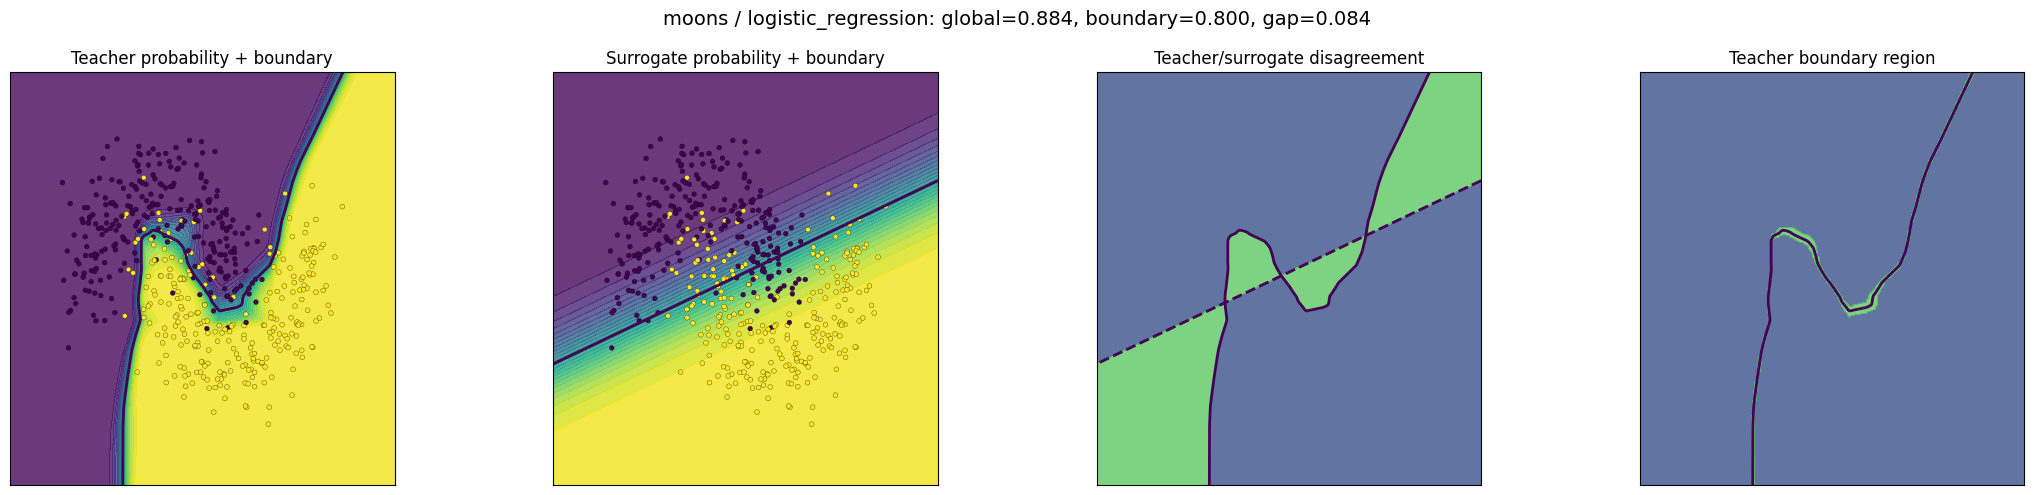

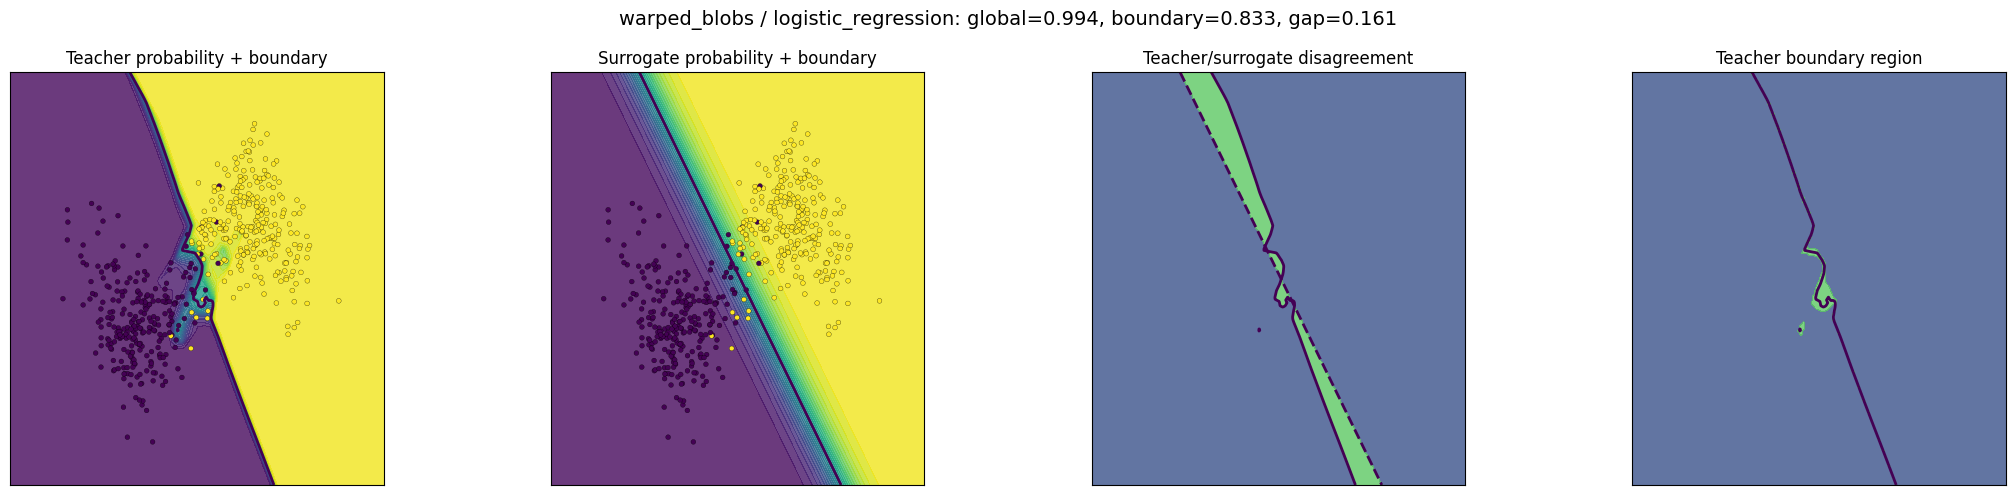

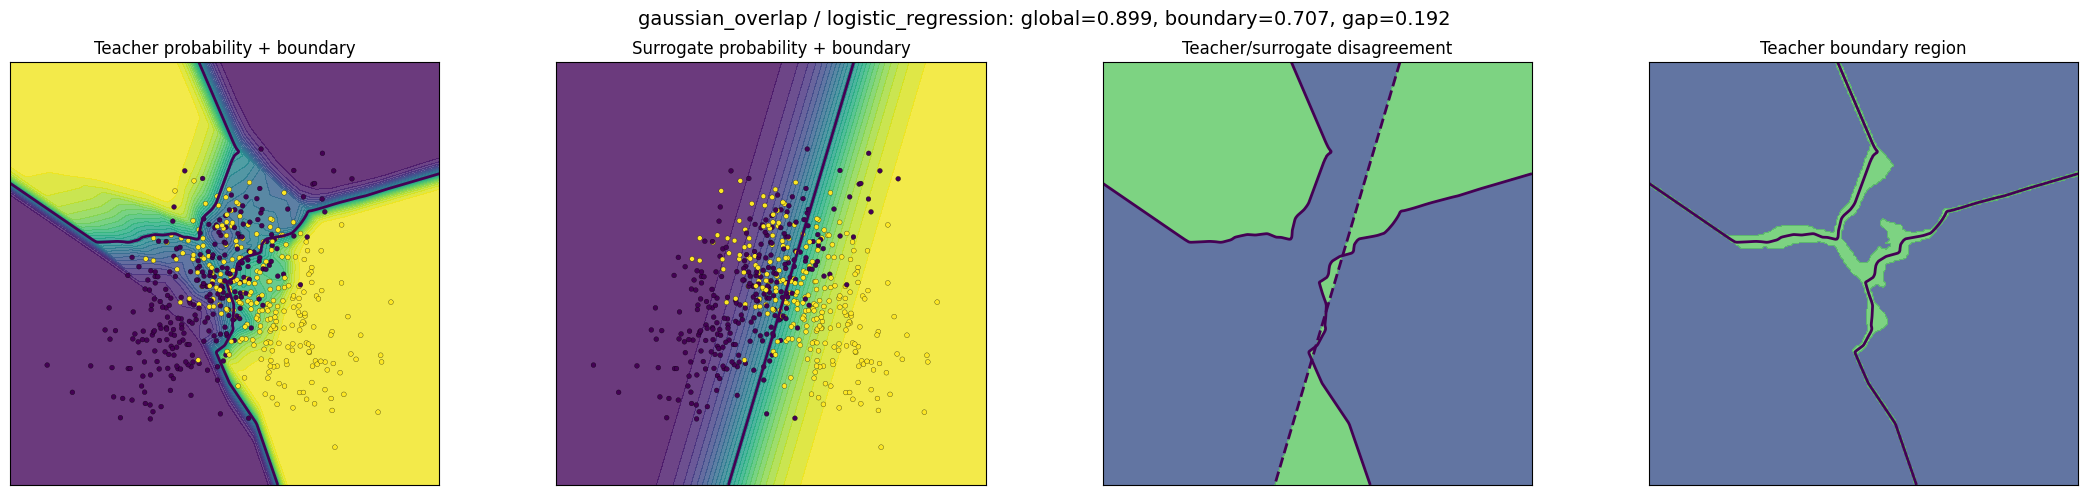

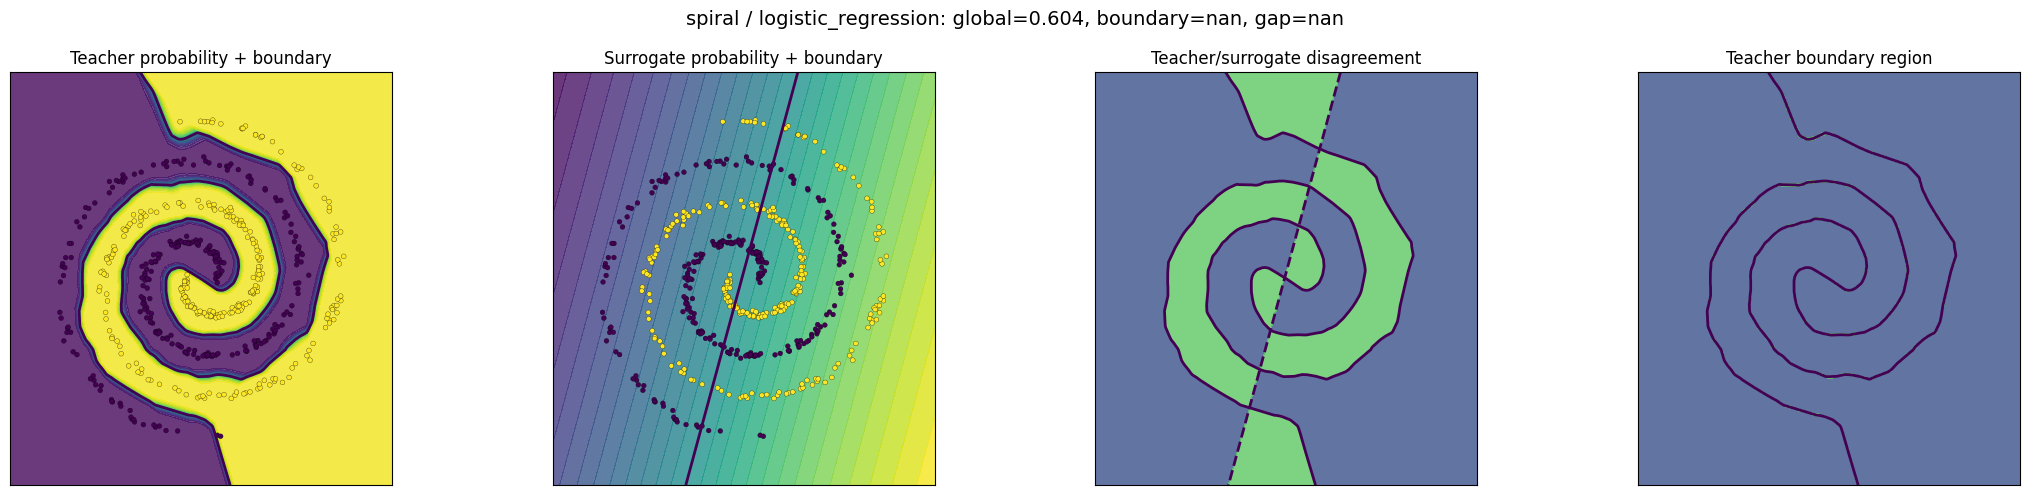

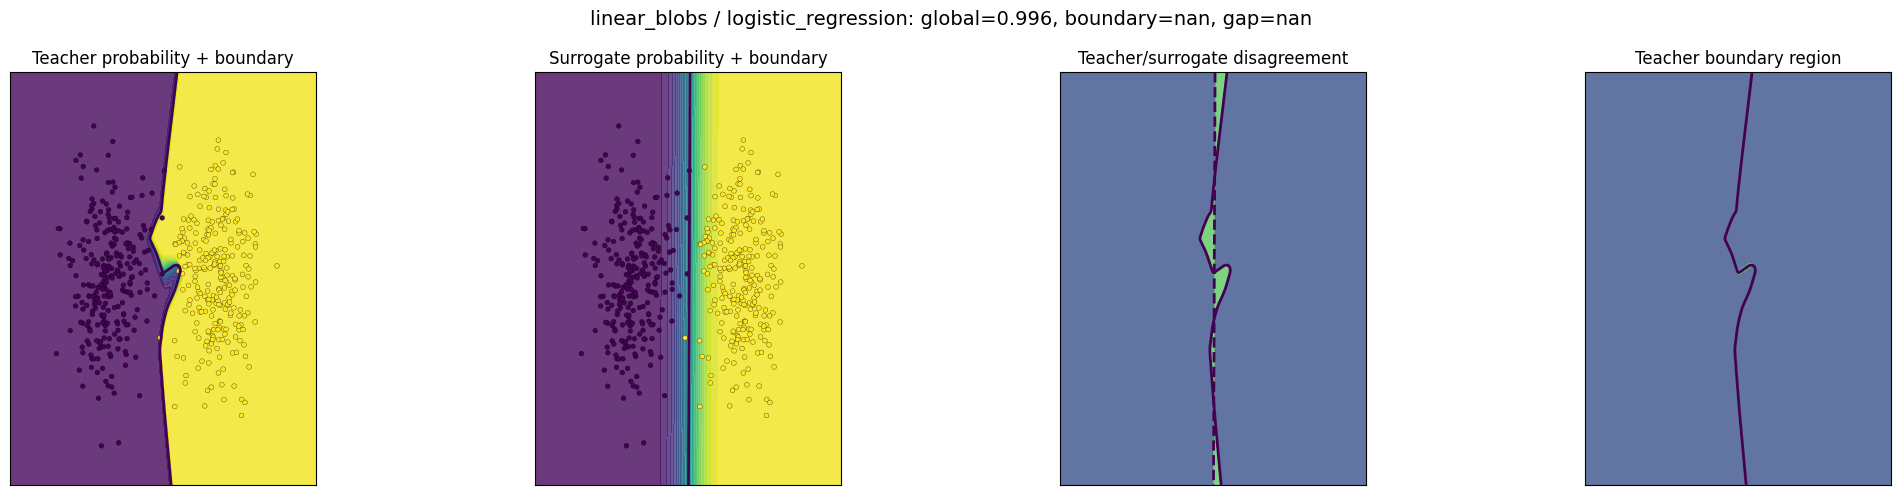

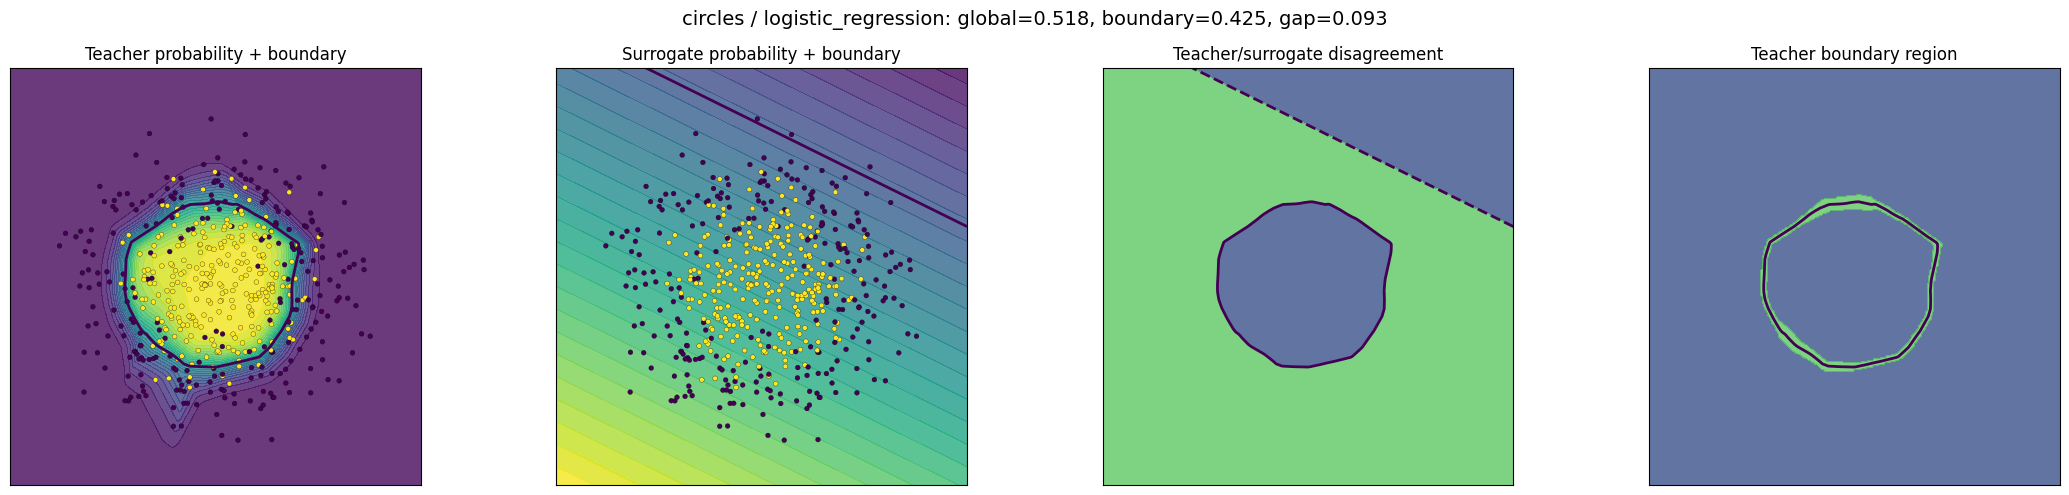

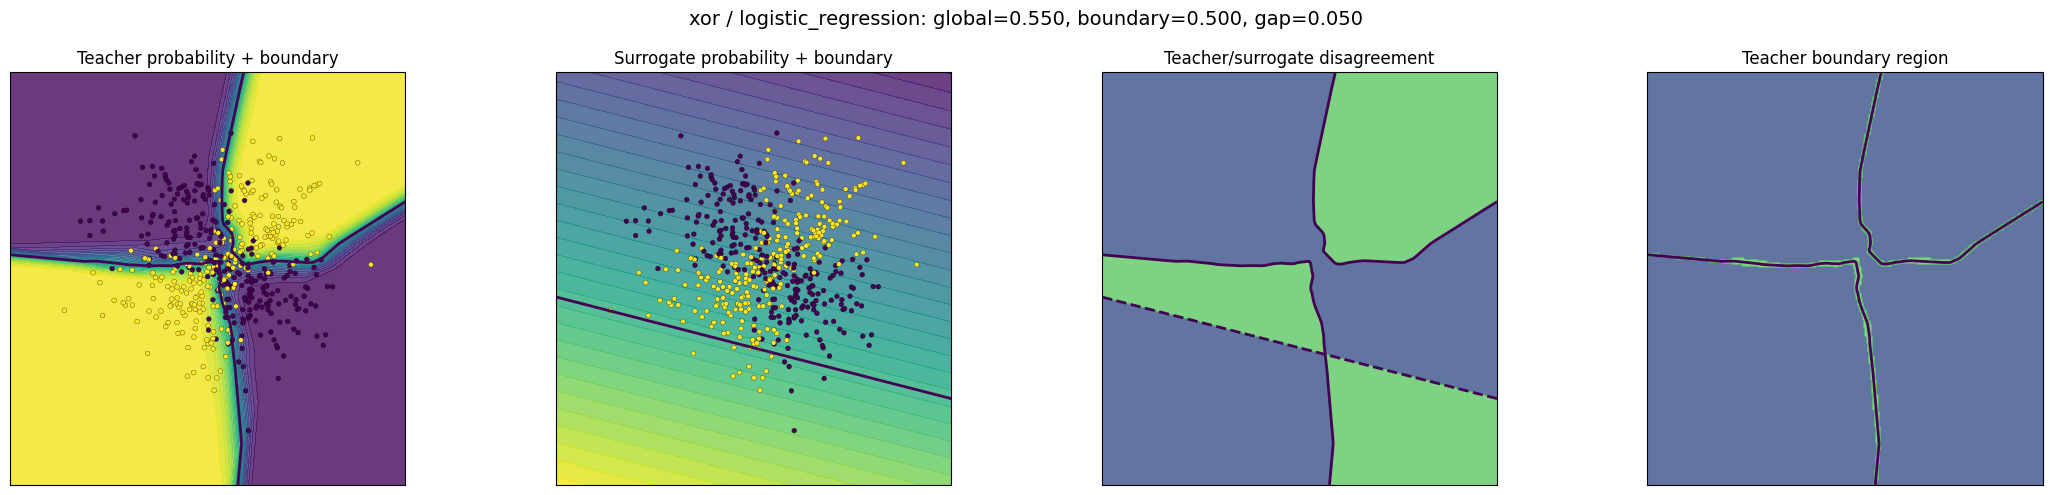

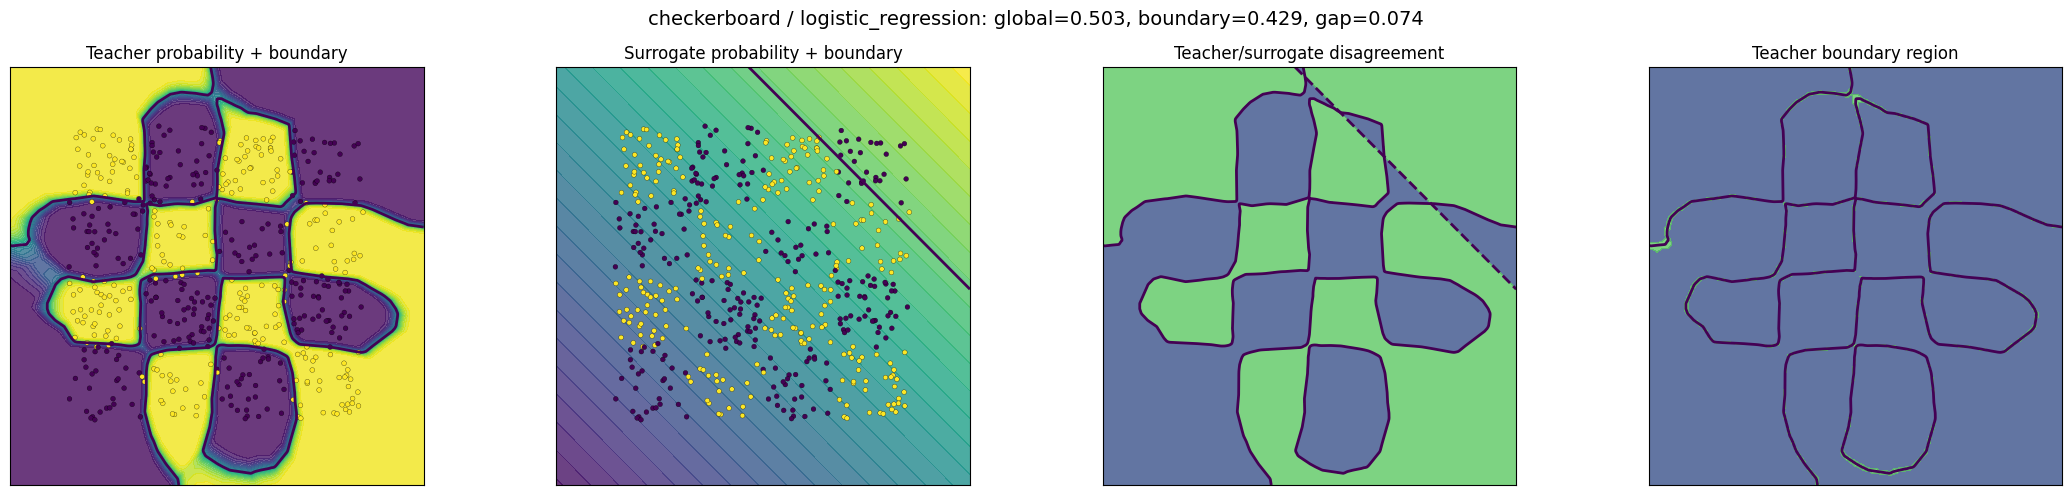

In [61]:
# Visualize representative 2D cases. Skip high_dimensional because it is 10D.
for dataset_name in [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "spiral",
    "linear_blobs",
    "circles",
    "xor",
    "checkerboard",
]:
    visualize_2d_case(dataset_name, surrogate_name="logistic_regression", seed=0, eps=0.10)


In [62]:
# Quick interpretation aid: positive cases are high global fidelity + high positive gap.
interpretation = dataset_summary.copy()
interpretation["candidate_positive_case"] = (
    (interpretation["global_fidelity_mean"] >= 0.75)
    & (interpretation["boundary_gap_mean"] >= 0.15)
)
interpretation["candidate_control_or_trivial"] = (
    (interpretation["global_fidelity_mean"] < 0.65)
    | (interpretation["boundary_gap_mean"].abs() < 0.05)
)
interpretation


,teacher_task_accuracy_mean,surrogate_task_accuracy_mean,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean,candidate_positive_case,candidate_control_or_trivial
dataset,,,,,,,,,,,,
linear_blobs,0.994286,0.994248,0.997524,0.002411,0.600000,0.516398,0.997676,0.398667,0.515087,0.000381,True,False
moons,0.931238,0.874857,0.904457,0.034826,0.572035,0.157388,0.911983,0.332422,0.155132,0.022286,True,False
high_dimensional,0.914095,0.847048,0.864000,0.071970,0.536111,0.348257,0.866595,0.321328,0.326017,0.006476,True,False
warped_blobs,0.969333,0.969143,0.990743,0.006145,0.696775,0.239589,0.994515,0.293968,0.237646,0.014095,True,False
gaussian_overlap,0.755429,0.747390,0.893067,0.051560,0.685735,0.120608,0.948766,0.207331,0.081581,0.215238,True,False
circles,0.850857,0.685524,0.741867,0.188368,0.535203,0.112419,0.758441,0.206664,0.139730,0.074095,False,False
xor,0.846476,0.682705,0.737943,0.203502,0.592040,0.107455,0.753596,0.145903,0.155140,0.097714,False,False
checkerboard,0.943238,0.544114,0.553410,0.077883,0.482051,0.142153,0.555431,0.071359,0.168272,0.034286,False,True


In [63]:
interpretation.to_csv("dataset_generalization_interpretation_flags.csv")
print("Saved dataset_generalization_interpretation_flags.csv")


Saved dataset_generalization_interpretation_flags.csv
